# DL Assignment (Member - 01)

In [1]:
model_01 = None
model_02 = None

## Importing Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
import seaborn as sns
from sklearn.metrics import classification_report

## Data Pre Processing

'fConc1' is inbetween 0 and 1

In [6]:
# Read the data as a dataframe
data_frame_original  = pd.read_csv('https://raw.githubusercontent.com/IT21034268/dl-assignment-2024/assignment-dataset/magic-gamma-telescope/gamma-telescope-data.csv')
data_frame_edited = data_frame_original

In [7]:
data_frame_edited.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [8]:
data_frame_edited = data_frame_edited.rename(columns={
                        'fLength': 'fLength_n',
                        'fWidth': 'fWidth_n',
                        'fSize': 'fSize_n',
                        'fConc': 'fConc_n',
                        'fAsym': 'fAsym_n',
                        'fM3Long': 'fM3Long_n',
                        'fM3Trans': 'fM3Trans_n',
                        'fAlpha': 'fAlpha_n',
                        'fDist': 'fDist_n'})

In [9]:
data_frame_edited.head()

,fLength_n,fWidth_n,fSize_n,fConc_n,fConc1,fAsym_n,fM3Long_n,fM3Trans_n,fAlpha_n,fDist_n,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [10]:
data_frame_edited['class'] = data_frame_edited['class'].replace({'g': 0, 'h': 1})

<ipython-input-10-4d0cfed76a1d>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_frame_edited['class'] = data_frame_edited['class'].replace({'g': 0, 'h': 1})


In [11]:
data_frame_edited.head()

,fLength_n,fWidth_n,fSize_n,fConc_n,fConc1,fAsym_n,fM3Long_n,fM3Trans_n,fAlpha_n,fDist_n,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,0
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,0
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,0
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,0
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,0


### Normalize and replace

In [12]:
def add_normalized_column(data_frame_edited, my_array, my_column):
    # Normalize the array
    my_array_normal = (my_array - np.min(my_array)) / (np.max(my_array) - np.min(my_array))
    # Create a DataFrame with the normalized array
    my_data_frame = pd.DataFrame(my_array_normal, columns=my_column)
    # Add the normalized column to the original DataFrame
    data_frame_edited[my_column] = my_data_frame[my_column]

In [13]:
add_normalized_column(data_frame_edited, data_frame_edited.iloc[:, 0:1].values, ['fLength_n'])
add_normalized_column(data_frame_edited, data_frame_edited.iloc[:, 1:2].values, ['fWidth_n'])
add_normalized_column(data_frame_edited, data_frame_edited.iloc[:, 2:3].values, ['fSize_n'])
add_normalized_column(data_frame_edited, data_frame_edited.iloc[:, 3:4].values, ['fConc_n'])
add_normalized_column(data_frame_edited, data_frame_edited.iloc[:, 6:7].values, ['fAsym_n'])
add_normalized_column(data_frame_edited, data_frame_edited.iloc[:, 7:8].values, ['fM3Long_n'])
add_normalized_column(data_frame_edited, data_frame_edited.iloc[:, 8:9].values, ['fM3Trans_n'])
add_normalized_column(data_frame_edited, data_frame_edited.iloc[:, 8:9].values, ['fAlpha_n'])
add_normalized_column(data_frame_edited, data_frame_edited.iloc[:, 9:10].values, ['fDist_n'])

In [14]:
data_frame_edited

,fLength_n,fWidth_n,fSize_n,fConc_n,fConc1,fAsym_n,fM3Long_n,fM3Trans_n,fAlpha_n,fDist_n,class
0,0.074306,0.062415,0.208043,0.430390,0.1982,0.620576,0.512493,0.445467,0.445467,0.163066,0
1,0.082815,0.045727,0.170668,0.587794,0.3773,0.623756,0.507944,0.070677,0.070677,0.412679,0
2,0.478241,0.530579,0.626818,0.027617,0.0187,0.468201,0.416540,0.855111,0.855111,0.516926,0
3,0.059212,0.037338,0.117445,0.683714,0.3922,0.570630,0.515219,0.116100,0.116100,0.233582,0
4,0.214774,0.120603,0.360674,0.345153,0.1832,0.632050,0.590373,0.051644,0.051644,0.718582,0
...,...,...,...,...,...,...,...,...,...,...,...
19015,0.051838,0.042581,0.199527,0.650756,0.3934,0.602182,0.541215,0.026921,0.026921,0.213530,1
19016,0.074757,0.026141,0.096363,0.593249,0.2784,0.605095,0.526076,0.964417,0.964417,0.498046,1
19017,0.215712,0.185389,0.445594,0.146153,0.0549,0.653983,0.509218,0.336652,0.336652,0.516377,1
19018,0.352326,0.299950,0.606919,0.092397,0.0683,0.417922,0.368263,0.940971,0.940971,0.823491,1


In [15]:
random_state = np.random.RandomState(seed=37)

for index, row in data_frame_edited.iterrows():
    s = random_state.randint(0, 999999)
    s = np.random.RandomState(seed=s).randint(0, 999999)
    s = np.random.RandomState(seed=s).randint(0, 999999)
    s = np.random.RandomState(seed=s).randint(0, 999999)
    s = np.random.RandomState(seed=s).randint(0, 999999)
    permutation = np.random.RandomState(seed=s).permutation( len(data_frame_edited) )
    data_frame_edited = data_frame_edited.iloc[permutation].reset_index(drop=True)
    s = np.random.RandomState(seed=s).randint(0, 999999)
    s = np.random.RandomState(seed=s).randint(0, 999999)
    s = np.random.RandomState(seed=s).randint(0, 999999)
    s = np.random.RandomState(seed=s).randint(0, 999999)
    permutation = np.random.RandomState(seed=s).permutation( len(data_frame_edited) )
    data_frame_edited = data_frame_edited.iloc[permutation].reset_index(drop=True)

In [16]:
data_frame_edited

,fLength_n,fWidth_n,fSize_n,fConc_n,fConc1,fAsym_n,fM3Long_n,fM3Trans_n,fAlpha_n,fDist_n,class
0,0.113644,0.061936,0.218125,0.449256,0.2649,0.529172,0.552149,0.022422,0.022422,0.333277,0
1,0.051712,0.063407,0.141543,0.456075,0.2186,0.564727,0.562977,0.007161,0.007161,0.262460,0
2,0.130429,0.062670,0.249024,0.276963,0.1292,0.520828,0.505412,0.000767,0.000767,0.328915,0
3,0.068887,0.097283,0.213335,0.293897,0.1424,0.587389,0.565539,0.614542,0.614542,0.323197,0
4,0.234557,0.104634,0.527558,0.200250,0.1038,0.709263,0.583545,0.003772,0.003772,0.525905,0
...,...,...,...,...,...,...,...,...,...,...,...
19015,0.063473,0.053075,0.127883,0.552108,0.2939,0.559367,0.563060,0.740544,0.740544,0.157120,0
19016,0.065745,0.087451,0.126257,0.836913,0.4090,0.561071,0.592589,0.174811,0.174811,0.728333,0
19017,0.065942,0.036365,0.156062,0.637345,0.4194,0.618811,0.521308,0.211578,0.211578,0.406339,0
19018,0.025200,0.046166,0.070698,0.780316,0.3729,0.565614,0.558723,0.696631,0.696631,0.123962,0


## Feature extraction

In [17]:
corr_matrix = data_frame_edited.corr()

In [18]:
corr_matrix

,fLength_n,fWidth_n,fSize_n,fConc_n,fConc1,fAsym_n,fM3Long_n,fM3Trans_n,fAlpha_n,fDist_n,class
fLength_n,1.000000,0.770512,0.702454,-0.630999,-0.598145,-0.119747,0.013389,-0.008777,-0.008777,0.418466,0.307572
fWidth_n,0.770512,1.000000,0.717517,-0.609779,-0.581141,-0.176234,0.039744,0.066061,0.066061,0.336816,0.265596
fSize_n,0.702454,0.717517,1.000000,-0.850850,-0.808835,0.095157,0.015455,-0.186675,-0.186675,0.437041,0.117795
fConc_n,-0.630999,-0.609779,-0.850850,1.000000,0.976412,-0.121899,-0.011294,0.235272,0.235272,-0.328332,-0.024615
fConc1,-0.598145,-0.581141,-0.808835,0.976412,1.000000,-0.118769,-0.010966,0.229799,0.229799,-0.304625,-0.004797
fAsym_n,-0.119747,-0.176234,0.095157,-0.121899,-0.118769,1.000000,-0.017197,-0.186275,-0.186275,0.037025,-0.193409
fM3Long_n,0.013389,0.039744,0.015455,-0.011294,-0.010966,-0.017197,1.000000,0.004659,0.004659,0.011427,0.003837
fM3Trans_n,-0.008777,0.066061,-0.186675,0.235272,0.229799,-0.186275,0.004659,1.000000,1.000000,-0.220556,0.460979
fAlpha_n,-0.008777,0.066061,-0.186675,0.235272,0.229799,-0.186275,0.004659,1.000000,1.000000,-0.220556,0.460979
fDist_n,0.418466,0.336816,0.437041,-0.328332,-0.304625,0.037025,0.011427,-0.220556,-0.220556,1.000000,0.065203


In [19]:
from sklearn.decomposition import PCA

x_param = data_frame_edited.drop('class', axis=1)
y_param = data_frame_edited['class']

pca = PCA(n_components=5)  # Choose the desired number of principal components
x_param_pca = pca.fit_transform(x_param)

In [20]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
rfe = RFE(model, n_features_to_select=5)  # Choose the desired number of features
x_param_rfe = rfe.fit_transform(x_param, y_param)

In [21]:
from sklearn.feature_selection import mutual_info_classif

mutual_info = mutual_info_classif(x_param, y_param)
mutual_info_df = pd.DataFrame({'feature': x_param.columns, 'mutual_info': mutual_info})
mutual_info_df = mutual_info_df.sort_values('mutual_info', ascending=False)

In [22]:
mutual_info_df

,feature,mutual_info
8,fAlpha_n,0.124060
7,fM3Trans_n,0.123982
1,fWidth_n,0.096957
0,fLength_n,0.085542
5,fAsym_n,0.077984
6,fM3Long_n,0.068677
2,fSize_n,0.052867
3,fConc_n,0.021697
9,fDist_n,0.013419
4,fConc1,0.011363


In [23]:
column_set_01 = ['fAlpha_n']
column_set_02 = ['fAlpha_n', 'fM3Trans_n']
column_set_03 = ['fAlpha_n', 'fM3Trans_n', 'fWidth_n']
column_set_04 = ['fAlpha_n', 'fM3Trans_n', 'fWidth_n', 'fLength_n']
column_set_05 = ['fAlpha_n', 'fM3Trans_n', 'fWidth_n', 'fLength_n', 'fAsym_n']
column_set_06 = ['fAlpha_n', 'fM3Trans_n', 'fWidth_n', 'fLength_n', 'fAsym_n', 'fM3Long_n']
column_set_07 = ['fAlpha_n', 'fM3Trans_n', 'fWidth_n', 'fLength_n', 'fAsym_n', 'fM3Long_n', 'fSize_n']
column_set_08 = ['fAlpha_n', 'fM3Trans_n', 'fWidth_n', 'fLength_n', 'fAsym_n', 'fM3Long_n', 'fSize_n', 'fConc_n']
column_set_09 = ['fAlpha_n', 'fM3Trans_n', 'fWidth_n', 'fLength_n', 'fAsym_n', 'fM3Long_n', 'fSize_n', 'fConc_n', 'fConc1']
column_set_10 = ['fAlpha_n', 'fM3Trans_n', 'fWidth_n', 'fLength_n', 'fAsym_n', 'fM3Long_n', 'fSize_n', 'fConc_n', 'fConc1', 'fDist_n']

In [24]:
my_lr = 0.01

In [25]:
my_e = 200

## 'model_01' details

In [26]:
columns_to_have_in_x0 = column_set_04
x0 = data_frame_edited[columns_to_have_in_x0]

In [27]:
x_var_count = len(columns_to_have_in_x0)

In [28]:
columns_to_have_in_y = ['class']
y = data_frame_edited[columns_to_have_in_y]

In [29]:
x0_train, x0_test, y_train, y_test = train_test_split(x0 , y, test_size=0.25, random_state=42)

In [30]:
x0_train_tensor = tf.convert_to_tensor(x0_train)
x0_test_tensor = tf.convert_to_tensor(x0_test)

In [31]:
y_train_tensor = tf.convert_to_tensor(y_train)
y_test_tensor = tf.convert_to_tensor(y_test)

In [32]:
model_01 = None

In [33]:
# Define the input shape for n independent variables
input_shape = (x_var_count,)  # Each input sample has n features

# Set the random seed
tf.random.set_seed(42)

# Create the model
model_01 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(4, activation='softsign'),
    tf.keras.layers.Dense(8, activation='swish'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation='softplus'),
    tf.keras.layers.Dense(4, activation='mish'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_01.compile(
                  loss=tf.keras.losses.BinaryCrossentropy(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=my_lr),
                  metrics=["accuracy"]
                )

# Fit the model
history_01 = model_01.fit(x0_train_tensor, y_train_tensor, epochs=my_e)

Epoch 1/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7321 - loss: 0.5347
Epoch 2/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7954 - loss: 0.4500
Epoch 3/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7983 - loss: 0.4431
Epoch 4/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8064 - loss: 0.4368
Epoch 5/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8055 - loss: 0.4360
Epoch 6/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8063 - loss: 0.4319
Epoch 7/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8057 - loss: 0.4340
Epoch 8/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8063 - loss: 0.4332
Epoch 9/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8122 - loss: 0.4306
Epoch 10/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8095 - loss: 0.4312
Epoch 11/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8078 - loss: 0.4329
Epoch 12/200
446/446 ━━━━━━━━━━━━━━━━━━━━

In [34]:
# Evaluate model_01 on the test dataset
evaluation_results = model_01.evaluate(x0_test_tensor, y_test_tensor)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8380 - loss: 0.3897


In [35]:
# Extract accuracy from evaluation results
accuracy = evaluation_results[1]

In [36]:
# Multiply accuracy by 100 and format it to 2 decimal points
accuracy_percentage = accuracy * 100

In [37]:
# Display the formatted accuracy
print(f"Model Accuracy on Test Dataset: {accuracy_percentage:.2f}%")

Model Accuracy on Test Dataset: 82.33%


149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


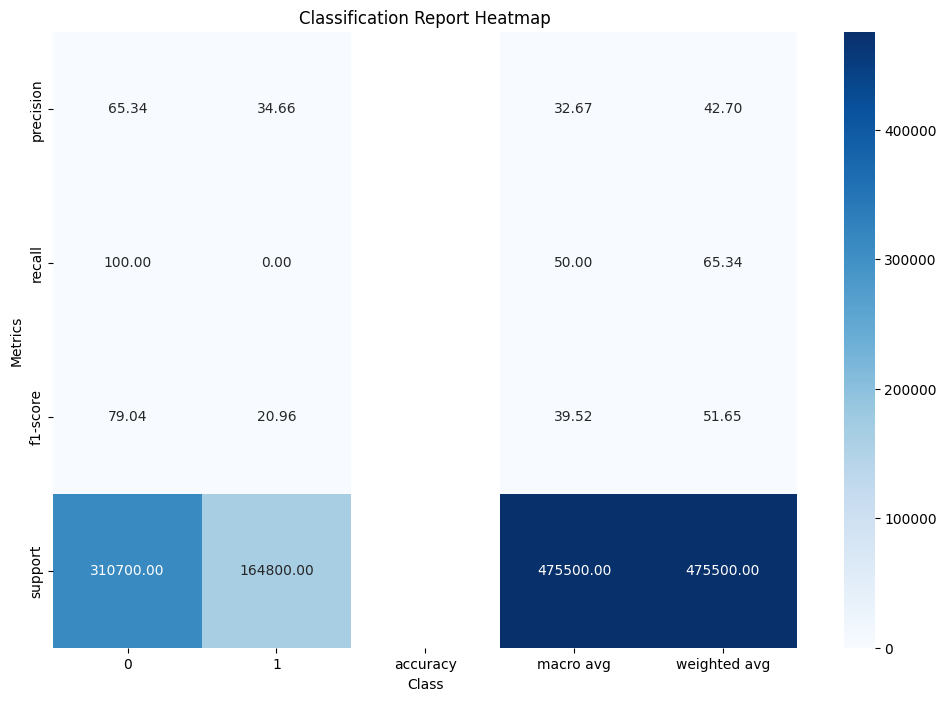

In [38]:
# Step 1: Make predictions using the model
y_pred_prob = model_01.predict(x0_test_tensor)

# Step 2: Convert predicted probabilities to class labels
y_pred = tf.argmax(y_pred_prob, axis=1).numpy()

# Step 3: Generate the classification report with zero_division parameter
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

# Step 4: Prepare data for visualization from the classification report
# Extract class labels dynamically from the report keys (including 'accuracy', 'macro avg', 'weighted avg')
class_labels = [key for key in report.keys()]

report_data = {
    "precision": [],
    "recall": [],
    "f1-score": [],
    "support": []
}

# Store precision, recall, f1-score for class labels
for label in class_labels:
    if isinstance(report[label], dict):  # Check if the label corresponds to a class
        report_data["precision"].append(report[label]['precision'] * 100)
        report_data["recall"].append(report[label]['recall'] * 100)
        report_data["f1-score"].append(report[label]['f1-score'] * 100)
        report_data["support"].append(report[label]['support'] * 100)
    else:  # For accuracy, macro avg, and weighted avg
        report_data["precision"].append(np.nan)  # Fill with NaN for non-class entries
        report_data["recall"].append(np.nan)
        report_data["f1-score"].append(np.nan)
        report_data["support"].append(np.nan)

# Subtract values of class label 0 from class label 1
if len(report_data['precision']) > 1:  # Ensure there are at least two classes
    report_data["precision"][1] = 100 - ( report_data["precision"][0] )
    report_data["recall"][1] = 100 - ( report_data["recall"][0] )
    report_data["f1-score"][1] = 100 - ( report_data["f1-score"][0] )

# Create a DataFrame for visualization
df = pd.DataFrame(report_data, index=class_labels)

# Step 5: Set up the figure for heatmap visualization
plt.figure(figsize=(12, 8))
sns.heatmap(df.T, annot=True, cmap="Blues", fmt='.2f', cbar=True)

# Add labels and title
plt.title('Classification Report Heatmap')
plt.xlabel('Class')
plt.ylabel('Metrics')

# Display the plot
plt.show()

## 'model_02' details

In [39]:
columns_to_have_in_x0 = column_set_05
x0 = data_frame_edited[columns_to_have_in_x0]

In [40]:
x_var_count = len(columns_to_have_in_x0)

In [41]:
columns_to_have_in_y = ['class']
y = data_frame_edited[columns_to_have_in_y]

In [42]:
x0_train, x0_test, y_train, y_test = train_test_split(x0 , y, test_size=0.25, random_state=42)

In [43]:
x0_train_tensor = tf.convert_to_tensor(x0_train)
x0_test_tensor = tf.convert_to_tensor(x0_test)

In [44]:
y_train_tensor = tf.convert_to_tensor(y_train)
y_test_tensor = tf.convert_to_tensor(y_test)

In [45]:
model_02 = None

In [46]:
# Define the input shape for n independent variables
input_shape = (x_var_count,)  # Each input sample has n features

# Set the random seed
tf.random.set_seed(42)

# Create the model
model_02 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(5, activation='mish'),
    tf.keras.layers.Dense(10, activation='softplus'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='swish'),
    tf.keras.layers.Dense(5, activation='softsign'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model_02.compile(
                  loss=tf.keras.losses.BinaryCrossentropy(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=my_lr),
                  metrics=["accuracy"]
                )

# Fit the model
history_02 = model_02.fit(x0_train_tensor, y_train_tensor, epochs=my_e)

Epoch 1/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6979 - loss: 0.5722
Epoch 2/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7909 - loss: 0.4550
Epoch 3/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7989 - loss: 0.4441
Epoch 4/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8050 - loss: 0.4392
Epoch 5/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8036 - loss: 0.4358
Epoch 6/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8048 - loss: 0.4349
Epoch 7/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8077 - loss: 0.4324
Epoch 8/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8070 - loss: 0.4294
Epoch 9/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8109 - loss: 0.4284
Epoch 10/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8095 - loss: 0.4276
Epoch 11/200
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8110 - loss: 0.4258
Epoch 12/200
446/446 ━━━━━━━━━━━━━━━━━━━━

In [47]:
# Evaluate model_02 on the test dataset
evaluation_results = model_02.evaluate(x0_test_tensor, y_test_tensor)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8361 - loss: 0.3768


In [48]:
# Extract accuracy from evaluation results
accuracy = evaluation_results[1]

In [49]:
# Multiply accuracy by 100 and format it to 2 decimal points
accuracy_percentage = accuracy * 100

In [50]:
# Display the formatted accuracy
print(f"Model Accuracy on Test Dataset: {accuracy_percentage:.2f}%")

Model Accuracy on Test Dataset: 82.48%


149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


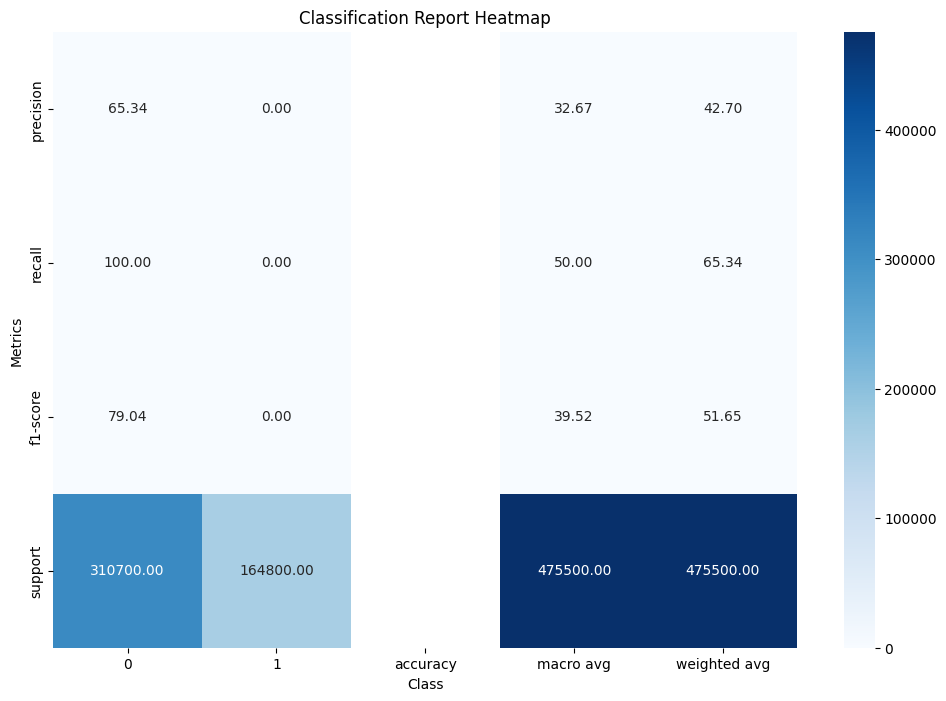

In [51]:
# Step 1: Make predictions using the model
y_pred_prob = model_02.predict(x0_test_tensor)

# Step 2: Convert predicted probabilities to class labels
y_pred = tf.argmax(y_pred_prob, axis=1).numpy()

# Step 3: Generate the classification report with zero_division parameter
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

# Step 4: Prepare data for visualization from the classification report
# Extract class labels dynamically from the report keys (including 'accuracy', 'macro avg', 'weighted avg')
class_labels = [key for key in report.keys()]

report_data = {
    "precision": [],
    "recall": [],
    "f1-score": [],
    "support": []
}

# Store precision, recall, f1-score for class labels
for label in class_labels:
    if isinstance(report[label], dict):  # Check if the label corresponds to a class
        report_data["precision"].append(report[label]['precision'] * 100)
        report_data["recall"].append(report[label]['recall'] * 100)
        report_data["f1-score"].append(report[label]['f1-score'] * 100)
        report_data["support"].append(report[label]['support'] * 100)
    else:  # For accuracy, macro avg, and weighted avg
        report_data["precision"].append(np.nan)  # Fill with NaN for non-class entries
        report_data["recall"].append(np.nan)
        report_data["f1-score"].append(np.nan)
        report_data["support"].append(np.nan)

# Create a DataFrame for visualization
df = pd.DataFrame(report_data, index=class_labels)

# Step 5: Set up the figure for heatmap visualization
plt.figure(figsize=(12, 8))
sns.heatmap(df.T, annot=True, cmap="Blues", fmt='.2f', cbar=True)

# Add labels and title
plt.title('Classification Report Heatmap')
plt.xlabel('Class')
plt.ylabel('Metrics')

# Display the plot
plt.show()